# Grover's Algorithm

Searching an unsorted list. Classically you check items one by one.
Grover checks in about the square root of that.

Each **iteration** is two parts: an **oracle** (mark the answer with a minus sign)
and a **diffuser** (turn that mark into a tall bar).

In [2]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

## n = 2 : searching 4 items, looking for |11>

One iteration. That's all it takes.

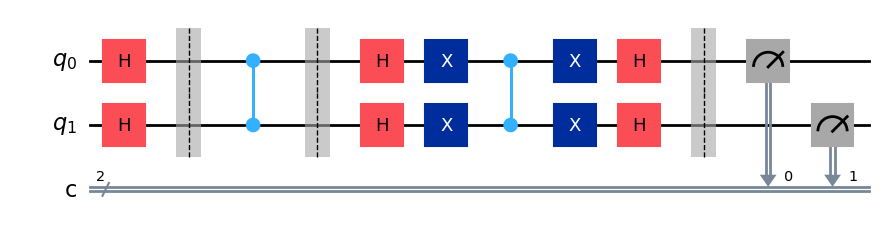

{'11': 1024}
P(11) = 1.0


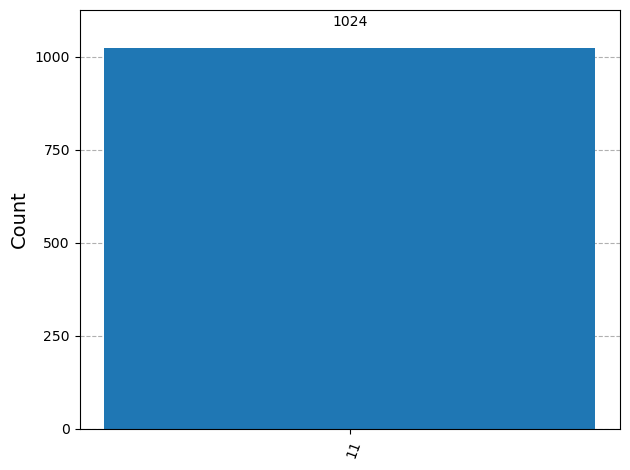

In [3]:
# GROVER n=2, ONE iteration, marked item = |11>

qc = QuantumCircuit(2, 2)

# all 4 items equally likely
qc.h(0)
qc.h(1)
qc.barrier()

# ORACLE - mark |11>
qc.cz(0, 1)
qc.barrier()

# DIFFUSER
qc.h(0)
qc.h(1)
qc.x(0)
qc.x(1)
qc.cz(0, 1)
qc.x(0)
qc.x(1)
qc.h(0)
qc.h(1)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)

display(qc.draw(output="mpl"))

counts = sim.run(transpile(qc, sim), shots=1024).result().get_counts()
print(counts)
print("P(11) =", counts.get("11", 0) / 1024)
display(plot_histogram(counts))

**100%.** Every shot found `11`.

With 4 items, classical searching needs about 2 guesses on average.
Grover needed **1** look at the oracle.

Four items is the lucky case - one iteration lands exactly on the answer.
It does not stay that easy.

## n = 3 : searching 8 items, looking for |111>

Same structure. Let's try one iteration again.

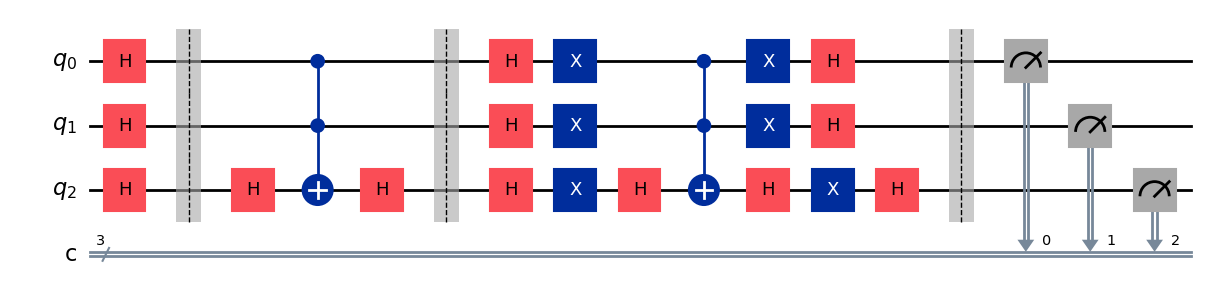

{'111': 1607, '100': 58, '010': 69, '110': 73, '101': 72, '001': 43, '011': 67, '000': 59}
P(111) = 0.78466796875


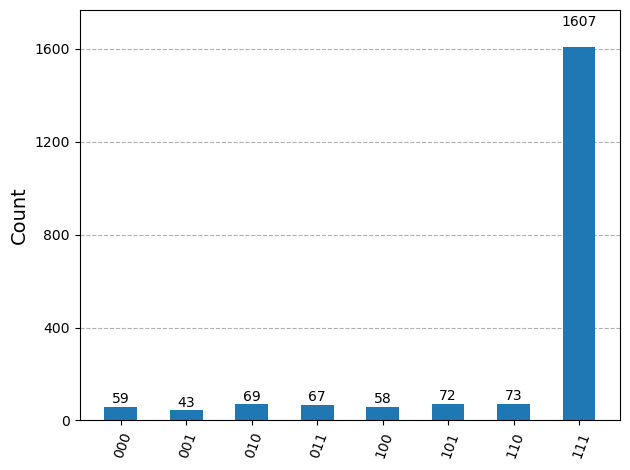

In [4]:
# GROVER n=3, ONE iteration, marked item = |111>

qc = QuantumCircuit(3, 3)

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ORACLE - mark |111>
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.barrier()

# DIFFUSER
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

display(qc.draw(output="mpl"))

counts = sim.run(transpile(qc, sim), shots=2048).result().get_counts()
print(counts)
print("P(111) =", counts.get("111", 0) / 2048)
display(plot_histogram(counts))

**About 78%.** Better than the 12.5% we started with - but not certain.

Roughly 1 in 5 runs gives the wrong answer. One iteration was not enough.

So we do it again.

## n = 3 : TWO iterations

Exactly the same oracle and diffuser, written out a second time.

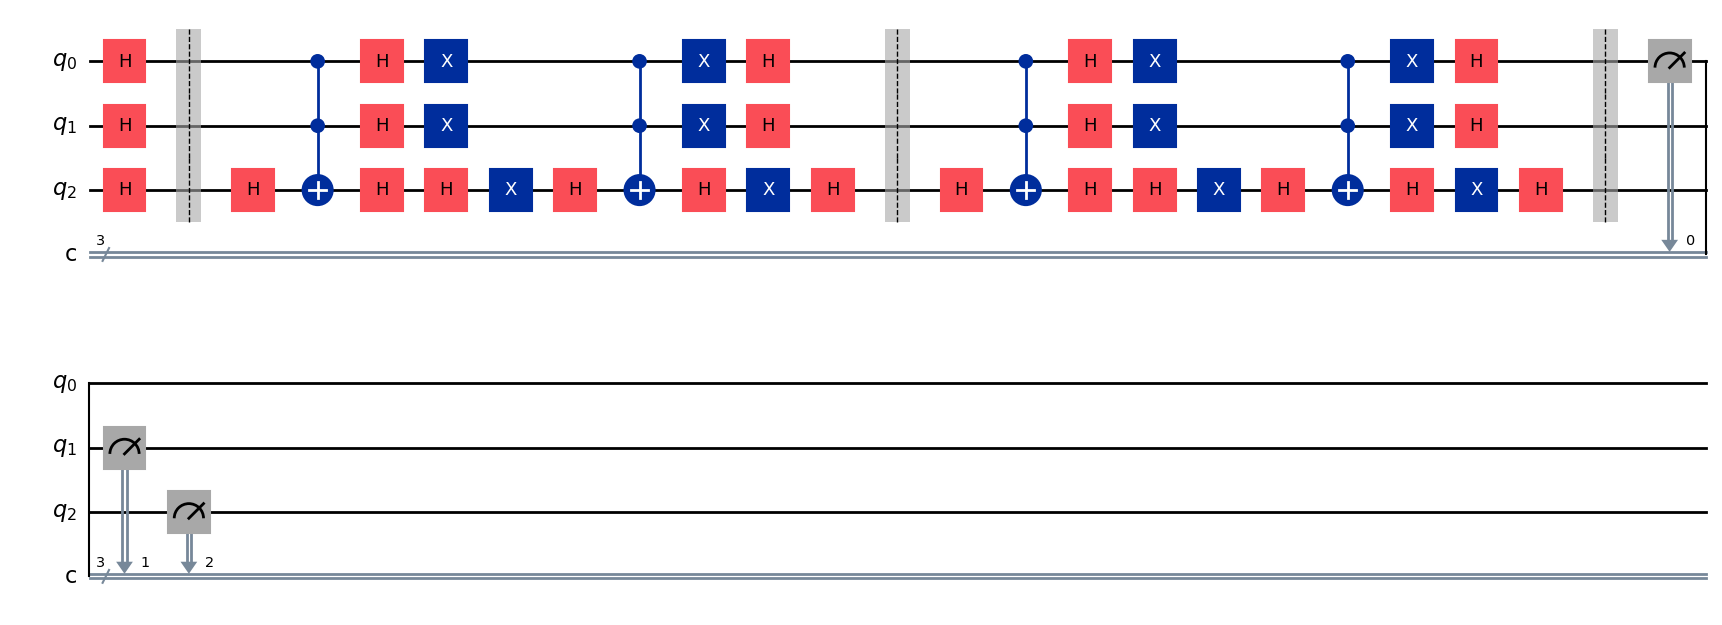

{'111': 1927, '101': 17, '001': 25, '000': 13, '011': 19, '100': 19, '110': 17, '010': 11}
P(111) = 0.94091796875


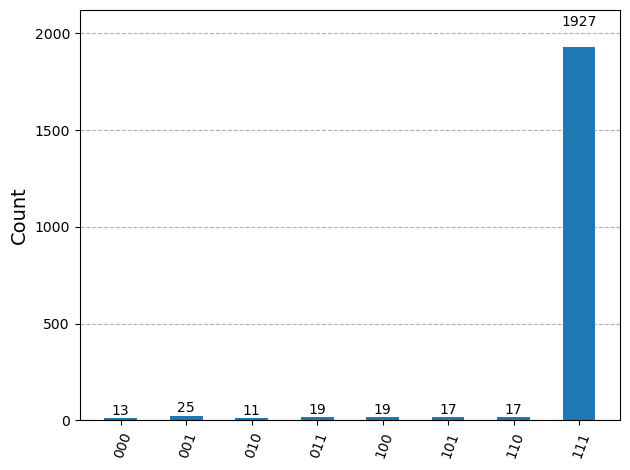

In [5]:
# GROVER n=3, TWO iterations, marked item = |111>

qc = QuantumCircuit(3, 3)

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ---------- ITERATION 1 ----------
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)

qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ---------- ITERATION 2 ----------
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)

qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

display(qc.draw(output="mpl"))

counts = sim.run(transpile(qc, sim), shots=2048).result().get_counts()
print(counts)
print("P(111) =", counts.get("111", 0) / 2048)
display(plot_histogram(counts))

**About 94%.** The second iteration pushed it up.

| items | iterations needed |
|---|---|
| 4 | 1 |
| 8 | 2 |

The rule is about `(pi/4) * sqrt(N)`. For 8 items that's 2.2, so 2.

## Now do NOT stop

If two is better than one, three should be better still.

**Predict before you run this.**

{'001': 174, '000': 197, '011': 205, '111': 688, '010': 200, '101': 196, '100': 189, '110': 199}
P(111) = 0.3359375


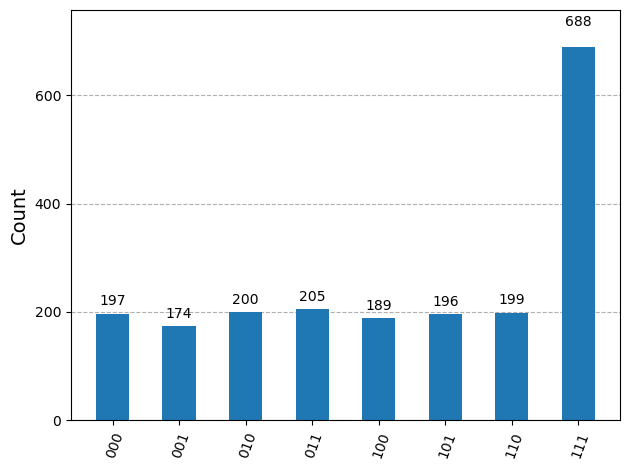

In [8]:
# GROVER n=3, THREE iterations, marked item = |111>

qc = QuantumCircuit(3, 3)

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ---------- ITERATION 1 ----------
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ---------- ITERATION 2 ----------
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ---------- ITERATION 3 ----------
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

counts = sim.run(transpile(qc, sim), shots=2048).result().get_counts()
print(counts)
print("P(111) =", counts.get("111", 0) / 2048)
display(plot_histogram(counts))

**It got worse.** Down to about 32%.

Grover's is not collecting evidence. It is **rotating a vector**.

Each iteration turns the state by a fixed angle towards the answer. Stop at the
right moment and you are pointing straight at it. Keep going and you rotate
past it and back out again.

That is why you need to know `sqrt(N)` in advance - not to go fast, but to know
when to **stop**.

## Summary

| N items | iterations | P(found) |
|---|---|---|
| 4 | 1 | 1.00 |
| 8 | 1 | 0.78 |
| 8 | 2 | 0.94 |
| 8 | 3 | 0.32 |

Classical search: N steps. Grover: about sqrt(N).

A million items goes from 1,000,000 steps to about 1,000. Real, and useful -
but **quadratic**, not exponential. Grover does not break encryption.